In [7]:
from datetime import datetime
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score

import xgboost as xg

import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Polygon
from sklearn.calibration import calibration_curve

RANDOM_SEED = 694973
np.random.seed(RANDOM_SEED)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
import sklearn
print("sklearn: "+sklearn.__version__)
print("xgboost: "+xg.__version__)

pandas: 3.0.1
numpy: 2.4.3
sklearn: 1.8.0
xgboost: 3.2.0


In [8]:
df = pd.read_csv('data/shot_probs_data.csv')
df.head()

,distance,angle,shot_type_numeric,shot_type,is_behind_backboard,set_name,is_made
0,0.187613,0.195018,0,JUMPER,0,train,0
1,0.029004,0.524437,1,LAYUP,0,train,0
2,0.115727,0.422763,0,JUMPER,0,train,1
3,0.256781,0.472390,0,JUMPER,0,train,1
4,0.109662,0.224862,0,JUMPER,0,train,1


In [9]:
def make_dataset(df:pd.DataFrame, set_name:str):
    dff = df.loc[df['set_name']==set_name].drop(['set_name','is_made','shot_type','shot_type_numeric'],axis=1).reset_index(drop=True)
    target = df.loc[df['set_name']==set_name]['is_made'].values
    shot_name_vals = df.loc[df['set_name']==set_name]['shot_type'].values
    return dff, target, shot_name_vals

X_train_mm, y_train, shot_train = make_dataset(df, 'train')
X_val_mm, y_val, shot_val = make_dataset(df, 'val')
X_query_mm, y_query, shot_query = make_dataset(df, 'query')
X_test_mm, y_test, shot_test = make_dataset(df, 'test')
X_old_mm, y_old, shot_old = make_dataset(df, 'old')

print(X_train_mm.shape, X_val_mm.shape, X_query_mm.shape, X_test_mm.shape, X_old_mm.shape)

(1612163, 3) (690928, 3) (493520, 3) (493519, 3) (0, 3)


In [10]:
X_train_mm.head()

,distance,angle,is_behind_backboard
0,0.187613,0.195018,0
1,0.029004,0.524437,0
2,0.115727,0.422763,0
3,0.256781,0.472390,0
4,0.109662,0.224862,0


In [11]:
def compute_scores(target, preds):
    loss = log_loss(target, preds)
    auc = roc_auc_score(target, preds)
    binary_preds = (preds >= 0.5).astype(int)
    accuracy = accuracy_score(target, binary_preds)
    return loss, auc, accuracy

def score_model(model, X, y, model_name=None):
    if model_name == 'nn':
        preds = model.predict_proba(X)
    else:
        preds = model.predict_proba(X)[:,1]
    loss, auc, acc = compute_scores(y, preds)
    print(f"Log Loss: {loss:.4f}, AUC: {auc:.4f}, Accuracy: {acc:.4f}")
    return None

In [12]:
def plot_cali_curve(truth, probs, label, color, nbins=30):
    prob_true, prob_pred = calibration_curve(truth, probs, n_bins=nbins)
    bindf = pd.DataFrame({'truth':truth, 'prob': probs})
    bin_edge = np.linspace(0, 1, nbins + 1)
    bindf['bin'] = pd.cut(bindf['prob'], bins=bin_edge)
    bin_counts = bindf.groupby('bin', observed=True).size().values
    plt.plot(prob_pred, prob_true, color=color, label=label)
    dot_sze = (bin_counts / bin_counts.max())*100
    plt.scatter(prob_pred, prob_true, color=color, s=dot_sze, label="_nolegend_")

In [ ]:
# xgboost params
xg_params = {
    'max_depth': [3],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [100, 200, 300],
    'gamma': [0, 0.1, 0.15, 0.3],
    'reg_lambda':[1, 10, 20, 50],
    'reg_alpha': [1, 5, 10],
}
xg_grid = ParameterGrid(xg_params)
best_score = float('inf')
best_params = None
best_iteration = 0
start = datetime.now()
for i, params in enumerate(xg_grid):
    model = xg.XGBClassifier(
        **params,
        n_estimators=3000,
        device='cuda',
        tree_method='hist',
        max_bin=512,
        eval_metric='logloss',
        early_stopping_rounds=200,
        monotone_constraints = (-1, 0, 0),
        random_state=RANDOM_SEED
    )
    model.fit(
        X_train_mm, y_train,
        eval_set=[(X_train_mm, y_train), (X_val_mm, y_val)],
        verbose=False
    )
    current_score = model.evals_result()['validation_1']['logloss'][model.best_iteration]
    if current_score < best_score:
        best_score = current_score
        best_params = params
        best_iteration = model.best_iteration
        best_model = model

end = datetime.now()

print('fit time: '+str(round((end - start).total_seconds()/60,2)))
print(best_params)
print(best_score)
print(best_iteration)

fit time: 184.05
{'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 100, 'reg_alpha': 10, 'reg_lambda': 1}
0.65321180293169
854


In [30]:
best_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",200
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [15]:
score_model(best_model, X_train_mm, y_train)
score_model(best_model, X_val_mm, y_val)

Log Loss: 0.6530, AUC: 0.6369, Accuracy: 0.6253
Log Loss: 0.6532, AUC: 0.6360, Accuracy: 0.6250


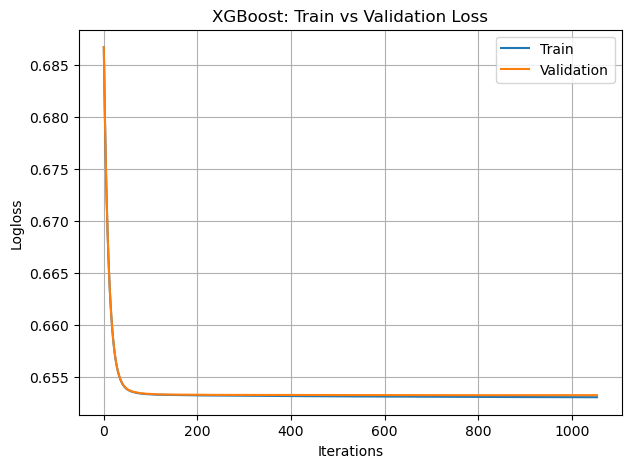

In [ ]:
results = best_model.evals_result()
train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(train_loss, label='Train')
ax.plot(val_loss, label='Validation')
ax.set_xlabel('Iterations')
ax.set_ylabel('Logloss')
ax.set_title('XGBoost: Train vs Validation Loss')
ax.legend()
ax.grid(True)

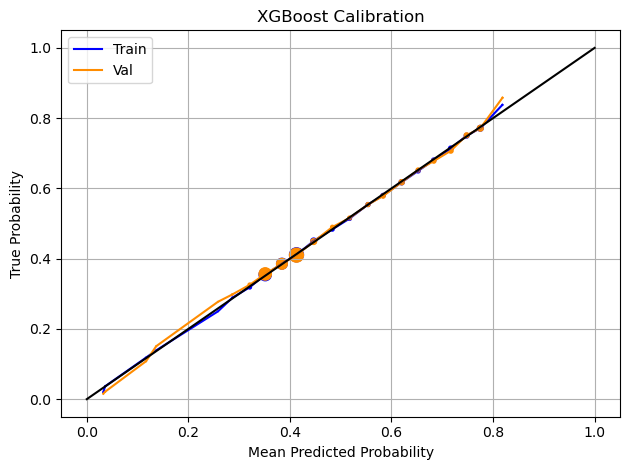

In [17]:
train_probs = best_model.predict_proba(X_train_mm)[:,1]
val_probs = best_model.predict_proba(X_val_mm)[:,1]
plot_cali_curve(y_train, train_probs, "Train", "blue")
plot_cali_curve(y_val, val_probs, "Val", "darkorange")
plt.title("XGBoost Calibration")
plt.ylabel("True Probability")
plt.xlabel("Mean Predicted Probability")
plt.legend(["Train", "Val"], loc="upper left")
plt.plot([0, 1], [0, 1], color='black')
plt.grid(True)
fig.set_size_inches(7, 5, forward=True)
plt.tight_layout()

In [18]:
best_xgb = xg.XGBClassifier(
    **best_params,
    n_estimators=best_iteration,
    device='cuda',
    tree_method='hist',
    max_bin=512,
    eval_metric='logloss',
    monotone_constraints = (-1, 0, 0),
    random_state=RANDOM_SEED
)
X_full_mm = np.concatenate((X_train_mm, X_val_mm))
y_full = np.concatenate((y_train, y_val))

best_xgb.fit(
    X_full_mm, y_full,
    verbose=False
) 
score_model(best_xgb, X_query_mm, y_query)
score_model(best_xgb, X_test_mm, y_test)

Log Loss: 0.6533, AUC: 0.6358, Accuracy: 0.6254
Log Loss: 0.6532, AUC: 0.6355, Accuracy: 0.6256


In [35]:
# ripped from stackoverflow
def draw_court_on_ax(ax, backboard_angle=150, if_backboard=True):
    ax.plot([-250, 250], [-40, -40], 'k-', zorder=2)
    ax.plot([-250, 250], [470, 470], 'k-', zorder=2)
    ax.plot([-250, -250], [-40, 470], 'k-', zorder=2)
    ax.plot([250, 250], [-40, 470], 'k-', zorder=2)
    ax.plot([-30, 30], [-10, -10], 'k-', zorder=2)
    ax.plot([-60, -60], [-40, 150], 'k-', zorder=2)
    ax.plot([60, 60], [-40, 150], 'k-', zorder=2)
    ax.plot([-80, -80], [-40, 150], 'k-', zorder=2)
    ax.plot([80, 80], [-40, 150], 'k-', zorder=2)
    ax.plot([-80, 80], [150, 150], 'k-', zorder=2)
    ax.plot([220, 220], [-40, 90], 'k-', zorder=2)
    ax.plot([-220, -220], [-40, 90], 'k-', zorder=2)
    three_point = Arc((0, 0),   width=475, height=475, theta1=22,  theta2=158, linewidth=1.5, zorder=2)
    top_key = Arc((0, 150), width=120, height=120, theta1=0,   theta2=180, linewidth=1.5, zorder=2)
    bottom_key = Arc((0, 150), width=120, height=120, theta1=180, theta2=360, linewidth=1.5, linestyle='--', zorder=2)
    basket = Arc((0, 0),   width=15,  height=15,  theta1=0,   theta2=360, linewidth=1.5, zorder=2)
    restricted = Arc((0, 7.5), width=80,  height=80,  theta1=0,   theta2=180, linewidth=1.5, zorder=2)
    half_court = Arc((0, 470), width=120, height=120, theta1=180, theta2=360, linewidth=1.5, zorder=2)

    # behind backboard
    if if_backboard:
        backboard_y = -10
        baseline_y = -40
        backboard_half_width = 30
        
        theta_rad = np.radians(backboard_angle / 2)
        height = backboard_y - baseline_y
        width = height * np.tan(theta_rad)
        
        top_left = (-backboard_half_width, backboard_y)
        top_right = (backboard_half_width, backboard_y)
        bottom_right = (backboard_half_width + width, baseline_y)
        bottom_left = (-backboard_half_width - width, baseline_y)
        
        behind = Polygon(
            [top_left, top_right, bottom_right, bottom_left], 
            closed=True, 
            color='black', 
            alpha=0.2, 
            zorder=1,
        )

    for patch in [three_point, top_key, bottom_key, basket, restricted, half_court]:
        ax.add_patch(patch)

    if if_backboard:
        ax.add_patch(behind)
    
    ax.set_xlim(-250, 250)
    ax.set_ylim(-40, 480)
    ax.set_aspect('equal')
    ax.axis('off')
    return ax

In [20]:
def define_behind_backboard(df, angle=150):
    theta_rad = np.radians(angle / 2)
    # directly behind
    behind = (df['yLegacy'] <= -10) & (df['yLegacy'] >= -40)
    depth = -10 - df['yLegacy']
    max_width = 30 + (depth * np.tan(theta_rad))
    in_width_range = df['xLegacy'].abs() <= max_width
    is_behind = behind & in_width_range
    return is_behind.astype(int)

In [21]:
yLegacy  = np.linspace(-40, 500, 200)
xLegacy = np.linspace(-250, 250, 200)
X, Y = np.meshgrid(xLegacy, yLegacy)

# scale
df = np.column_stack([X.ravel(), Y.ravel()])
df = pd.DataFrame(df, columns=['xLegacy','yLegacy'])
df['distance'] = np.sqrt((df["xLegacy"]/10)**2 + (df["yLegacy"]/10)**2)
df['angle'] = np.degrees(np.arctan2(df['xLegacy'].abs(), df['yLegacy']))
df['is_behind_backboard'] = define_behind_backboard(df, angle=150)

num_cols = ['distance', 'angle']
mm_scaler = joblib.load('data/mm_scaler.pkl')
grid_mm = mm_scaler.transform(df[num_cols])
grid_mm = pd.DataFrame(grid_mm, columns=num_cols, index=df.index)
grid_mm['is_behind_backboard'] = df['is_behind_backboard']
preds = best_xgb.predict_proba(grid_mm[['distance','angle','is_behind_backboard']])[:,1]
Z = preds.reshape(X.shape)
grid_mm.head()

,distance,angle,is_behind_backboard
0,0.281597,0.550502,0
1,0.278838,0.551006,0
2,0.276080,0.551520,0
3,0.273322,0.552044,0
4,0.270565,0.552579,0


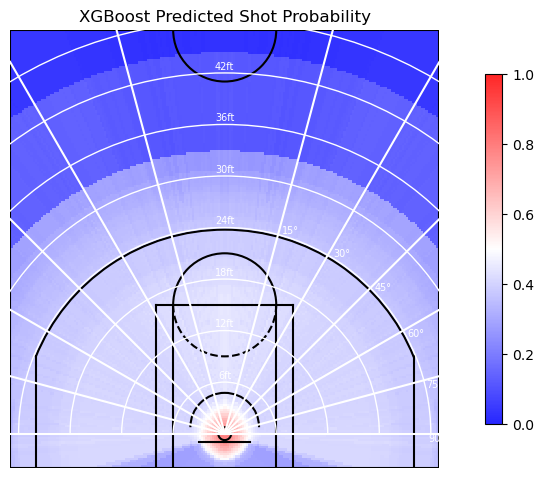

In [36]:
fig, ax = plt.subplots(figsize=(9, 4.5))
draw_court_on_ax(ax, if_backboard=False)
im = ax.pcolormesh(
    X, Y, Z,
    cmap='bwr',
    alpha=0.85,
    vmin=0, vmax=1,
    zorder=1,
    shading='auto'
)
plt.colorbar(im, ax=ax, shrink=0.8)

for dist_ft in range(6, 49, 6):
    dist_units = dist_ft * 10
    ring = Arc((0, 0), width=dist_units*2, height=dist_units*2,
                theta1=0, theta2=180,
                color='white', zorder=3)
    ax.add_patch(ring)
    ax.text(0, dist_units + 2.5, f"{dist_ft}ft",
    fontsize=7, color='white', ha='center', va='bottom', zorder=3)
    # angle
    angle_label_coords = {
        15: (67, 237),
        30: (127, 210),
        45: (175, 170),
        60: (213, 117),
        75: (235, 57),
        90: (237, -5),
    }
for angle_deg in range(15, 101, 15):
    angle_rad_line = np.radians(angle_deg)
    for sign in [-1, 1]:
        x_end = sign*500*np.sin(angle_rad_line)
        y_end = 500*np.cos(angle_rad_line)
        ax.plot([0, x_end], [0, y_end], color='white', zorder=3)
    x_label, y_label = angle_label_coords[angle_deg]
    ax.text(x_label, y_label, f"{angle_deg}°",
        color='white', fontsize=7,
        ha='left', va='center', zorder=3
    )
ax.set_xlim(-250, 250)
ax.set_ylim(-40, 470)
ax.set_title("XGBoost Predicted Shot Probability")
plt.tight_layout(pad=-0.3)

In [23]:
# make preds for data
df = pd.read_csv('data/nba_api_code/nba_shots_pbp.csv')
df['distance'] = np.sqrt((df["xLegacy"]/10)**2 + (df["yLegacy"]/10)**2)
df['angle'] = np.degrees(np.arctan2(np.sqrt(df['xLegacy']**2), df['yLegacy']))

# codify shot type
layups = ['Tip Layup Shot','Driving Layup Shot','Running Layup Shot','Cutting Layup Shot','Driving Reverse Layup Shot','Layup Shot',
          'Driving Finger Roll Layup Shot','Running Reverse Layup Shot','Running Finger Roll Layup Shot','Alley Oop Layup shot','Putback Layup Shot',
          'Reverse Layup Shot','Finger Roll Layup Shot','Cutting Finger Roll Layup Shot','Running Alley Oop Layup Shot','Running Tip Shot','Tip Shot'
          ]
jumper = ['Jump Shot','Driving Floating Bank Jump Shot','Driving Floating Jump Shot','Fadeaway Jump Shot', 'Step Back Jump shot','Running Jump Shot',
          'Pullup Jump shot','Floating Jump shot','Running Pull-Up Jump Shot','Turnaround Fadeaway Bank Jump Shot', 'Jump Bank Shot',
          'Turnaround Jump Shot','Step Back Bank Jump Shot', 'Turnaround Fadeaway shot','Turnaround Bank shot','Fadeaway Bank shot',
          'Driving Jump shot','Driving Bank shot','Running Bank shot','Pullup Bank shot'
          ]
dunk = ['Running Dunk Shot', 'Cutting Dunk Shot','Driving Dunk Shot','Putback Dunk Shot','Running Alley Oop Dunk Shot', 'Tip Dunk Shot', 'Dunk Shot',
        'Reverse Dunk Shot', 'Alley Oop Dunk Shot','Running Reverse Dunk Shot','Driving Reverse Dunk Shot','Putback Reverse Dunk Shot',
        'Running Slam Dunk Shot','Driving Slam Dunk Shot','Reverse Slam Dunk Shot','Putback Slam Dunk Shot','Slam Dunk Shot'
        ]
hook = ['Hook Shot','Turnaround Bank Hook Shot','Turnaround Hook Shot', 'Driving Hook Shot', 'Hook Bank Shot','Driving Bank Hook Shot',
        'Running Bank Hook Shot','Jump Bank Hook Shot','Jump Hook Shot','Running Hook Shot'
        ]
df = df.dropna(subset=['subType']).reset_index(drop=True)
df['shot_type'] = np.where(df['subType'].isin(layups),"LAYUP",'OTH')
df['shot_type'] = np.where(df['subType'].isin(jumper),"JUMPER",df['shot_type'])
df['shot_type'] = np.where(df['subType'].isin(dunk),"DUNK",df['shot_type'])
df['shot_type'] = np.where(df['subType'].isin(hook),"HOOK",df['shot_type'])
df['is_behind_backboard'] = define_behind_backboard(df)
df = df.dropna(subset=['distance','angle']).reset_index(drop=True)
df['is_made'] = np.where(df['shotResult']=='Made',1,0)

pred_df = df.copy()
pred_df[['distance','angle']] = mm_scaler.transform(pred_df[['distance','angle']])
pred_df.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,SEASON,distance,angle,shot_type,is_behind_backboard,is_made
0,21000001,2,PT11M43.00S,1,1610612738,BOS,406,O'Neal,S. O'Neal,-4,...,1.610613e+09,MIA,NaN,NaN,2010-11,0.013018,0.111017,LAYUP,0,0
1,21000001,8,PT10M53.00S,1,1610612748,MIA,2544,James,L. James,144,...,1.610613e+09,MIA,NaN,NaN,2010-11,0.219541,0.260265,JUMPER,0,1
2,21000001,9,PT10M35.00S,1,1610612738,BOS,1718,Pierce,P. Pierce,165,...,1.610613e+09,MIA,NaN,NaN,2010-11,0.205431,0.351646,JUMPER,0,0
3,21000001,11,PT10M27.00S,1,1610612748,MIA,2548,Wade,D. Wade,21,...,1.610613e+09,MIA,NaN,NaN,2010-11,0.024621,0.397584,LAYUP,0,0
4,21000001,14,PT10M02.00S,1,1610612748,MIA,2544,James,L. James,-152,...,1.610613e+09,MIA,NaN,NaN,2010-11,0.206749,0.304758,JUMPER,0,0


In [24]:
pred_df['logits'] = best_xgb.predict(pred_df[['distance','angle','is_behind_backboard']], output_margin=True)
pred_df['probs'] = best_xgb.predict_proba(pred_df[['distance','angle','is_behind_backboard']])[:,1]
pred_df.head()

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,defTeamId,defTeamTricode,SEASON,distance,angle,shot_type,is_behind_backboard,is_made,logits,probs
0,21000001,2,PT11M43.00S,1,1610612738,BOS,406,O'Neal,S. O'Neal,-4,...,NaN,NaN,2010-11,0.013018,0.111017,LAYUP,0,0,0.898992,0.710742
1,21000001,8,PT10M53.00S,1,1610612748,MIA,2544,James,L. James,144,...,NaN,NaN,2010-11,0.219541,0.260265,JUMPER,0,1,-0.443567,0.390891
2,21000001,9,PT10M35.00S,1,1610612738,BOS,1718,Pierce,P. Pierce,165,...,NaN,NaN,2010-11,0.205431,0.351646,JUMPER,0,0,-0.419127,0.396726
3,21000001,11,PT10M27.00S,1,1610612748,MIA,2548,Wade,D. Wade,21,...,NaN,NaN,2010-11,0.024621,0.397584,LAYUP,0,0,0.285373,0.570863
4,21000001,14,PT10M02.00S,1,1610612748,MIA,2544,James,L. James,-152,...,NaN,NaN,2010-11,0.206749,0.304758,JUMPER,0,0,-0.406330,0.399793


In [25]:
pred_df.shape

(3290130, 39)

In [31]:
pred_df.to_csv('data/baseline_probs.csv', index=False)

In [32]:
def score_preds_by_season(df, target_col='is_made', pred_col='probs', season_col='SEASON'):
    overall_loss, overall_auc, overall_acc = compute_scores(df[target_col], df[pred_col])
    print(f"Log Loss: {overall_loss:.4f} | AUC: {overall_auc:.4f} | Accuracy: {overall_acc:.4f}\n")
    
    season_results = []
    for season, group in df.groupby(season_col):
        loss, auc, acc = compute_scores(group[target_col], group[pred_col])
        season_results.append({
            'Season': season,
            'Sample Size': len(group),
            'Log Loss': round(loss, 4),
            'AUC': round(auc, 4),
            'Accuracy': round(acc, 4)
        })
    results_df = pd.DataFrame(season_results)
    print(results_df.to_string(index=False))
    return results_df

results_df = score_preds_by_season(pred_df, target_col='is_made', pred_col='probs', season_col='SEASON')

Log Loss: 0.6531 | AUC: 0.6364 | Accuracy: 0.6253

 Season  Sample Size  Log Loss    AUC  Accuracy
2010-11       199790    0.6569 0.6264    0.6233
2011-12       161225    0.6543 0.6295    0.6298
2012-13       201609    0.6557 0.6269    0.6253
2013-14       204172    0.6558 0.6266    0.6250
2014-15       205570    0.6526 0.6311    0.6270
2015-16       208028    0.6548 0.6290    0.6226
2016-17       210054    0.6559 0.6304    0.6195
2017-18       211707    0.6497 0.6376    0.6299
2018-19       219458    0.6484 0.6437    0.6325
2019-20       188116    0.6479 0.6437    0.6346
2020-21       190983    0.6552 0.6354    0.6227
2021-22       215168    0.6505 0.6450    0.6286
2022-23       216862    0.6524 0.6486    0.6226
2023-24       218702    0.6535 0.6442    0.6202
2024-25       219527    0.6533 0.6439    0.6209
2025-26       219159    0.6537 0.6477    0.6218


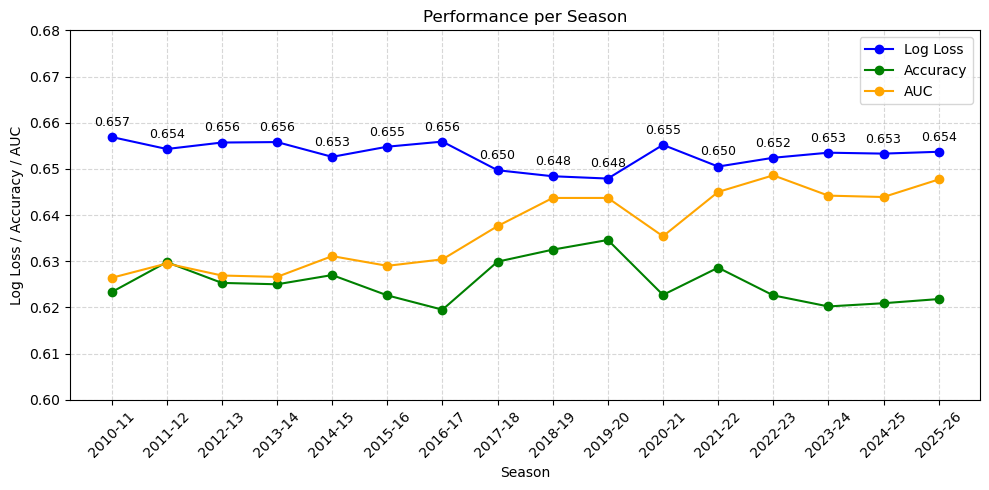

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(results_df['Season'], results_df['Log Loss'], marker='o', color='blue',label='Log Loss')
plt.plot(results_df['Season'], results_df['Accuracy'], marker='o', color='green', label='Accuracy')
plt.plot(results_df['Season'], results_df['AUC'], marker='o', color='orange', label='AUC')
for x, y in zip(results_df['Season'], results_df['Log Loss']):
    plt.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)
plt.title('Performance per Season')
plt.xlabel('Season')
plt.ylabel('Log Loss / Accuracy / AUC')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0.60, 0.68)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
def score_preds_by_shot_type(df, target_col='is_made', pred_col='probs', shot_type_col='shot_type'):
    overall_loss, overall_auc, overall_acc = compute_scores(df[target_col], df[pred_col])
    print(f"Log Loss: {overall_loss:.4f} | AUC: {overall_auc:.4f} | Accuracy: {overall_acc:.4f}\n")
    shot_order = ['JUMPER', 'DUNK', 'HOOK', 'LAYUP']
    shot_results = []
    for shot in shot_order:
        group = df[df[shot_type_col] == shot]
        loss, auc, acc = compute_scores(group[target_col], group[pred_col])
        shot_results.append({
            'Shot Type': shot,
            'Sample Size': len(group),
            'Log Loss': round(loss, 4),
            'AUC': round(auc, 4),
            'Accuracy': round(acc, 4)
        })
    results_df = pd.DataFrame(shot_results)
    return results_df

results_df = score_preds_by_shot_type(pred_df, target_col='is_made', pred_col='probs', shot_type_col='shot_type')
results_df

Log Loss: 0.6531 | AUC: 0.6364 | Accuracy: 0.6253



,Shot Type,Sample Size,Log Loss,AUC,Accuracy
0,JUMPER,2143411,0.6616,0.5371,0.6187
1,DUNK,179082,0.4384,0.6411,0.8644
2,HOOK,107654,0.6972,0.5356,0.5256
3,LAYUP,859983,0.6711,0.6130,0.6044
